# Feature Engineering - Cyberbullying Classification

## Import Libraries and Load Data

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud, STOPWORDS
import re
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv('../data/cyberbullying.csv')
print("Original Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Original Dataset Shape: (47692, 2)

First few rows:
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying


## Text Cleaning Function

In [3]:
def clean_text(text):
    """
    Clean and preprocess text data.
    - Convert to lowercase
    - Remove URLs
    - Remove @mentions
    - Remove #hashtags
    - Remove punctuation and numbers
    - Remove extra whitespace
    """
    text = text.lower()                         # lowercase
    text = re.sub(r"http\S+", "", text)         # remove URLs
    text = re.sub(r"@\w+", "", text)            # remove mentions
    text = re.sub(r"#\w+", "", text)            # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)        # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

# Test the cleaning function
sample_text = df['tweet_text'].iloc[0]
print("Original Text:")
print(repr(sample_text[:100]))
print("\nCleaned Text:")
print(repr(clean_text(sample_text)[:100]))

Original Text:
'In other words #katandandre, your food was crapilicious! #mkr'

Cleaned Text:
'in other words your food was crapilicious'


## Preprocessing Pipeline

In [4]:
preprocessed_df = df.copy()

# Step 1: Check and drop null values
print("Step 1: Handling Missing Values")
print(f"Missing values: {preprocessed_df.isnull().sum().sum()}")
preprocessed_df = preprocessed_df.dropna(subset=['tweet_text', 'cyberbullying_type'])
print(f"Shape after removing nulls: {preprocessed_df.shape}")

# Step 2: Remove duplicate tweets
print("\nStep 2: Removing Duplicates")
initial_size = len(preprocessed_df)
preprocessed_df = preprocessed_df.drop_duplicates(subset=['tweet_text']).reset_index(drop=True)
print(f"Duplicates removed: {initial_size - len(preprocessed_df)}")
print(f"Shape after removing duplicates: {preprocessed_df.shape}")

# Step 3: Remove unwanted class
print("\nStep 3: Removing 'other_cyberbullying' class")
initial_size = len(preprocessed_df)
preprocessed_df = preprocessed_df[preprocessed_df['cyberbullying_type'] != 'other_cyberbullying'].reset_index(drop=True)
print(f"Samples removed: {initial_size - len(preprocessed_df)}")
print(f"Shape after removing class: {preprocessed_df.shape}")

# Step 4: Remove empty tweets
print("\nStep 4: Removing empty tweets")
initial_size = len(preprocessed_df)
preprocessed_df = preprocessed_df[preprocessed_df['tweet_text'].astype(str).str.strip() != ""]
preprocessed_df.reset_index(drop=True, inplace=True)
print(f"Empty tweets removed: {initial_size - len(preprocessed_df)}")

# Step 5: Apply text cleaning
print("\nStep 5: Applying text cleaning function")
preprocessed_df['cleaned_text'] = preprocessed_df['tweet_text'].apply(clean_text)

# Step 6: Remove empty after cleaning
initial_size = len(preprocessed_df)
preprocessed_df = preprocessed_df[preprocessed_df['cleaned_text'].astype(str).str.strip() != ""].reset_index(drop=True)
preprocessed_df = preprocessed_df[preprocessed_df['cleaned_text'].str.len()>0]
print(f"Empty after cleaning: {initial_size - len(preprocessed_df)}")
print(f"Final shape after preprocessing: {preprocessed_df.shape}")

print("\n Text cleaning process complete!")

Step 1: Handling Missing Values
Missing values: 0
Shape after removing nulls: (47692, 2)

Step 2: Removing Duplicates
Duplicates removed: 1675
Shape after removing duplicates: (46017, 2)

Step 3: Removing 'other_cyberbullying' class
Samples removed: 6243
Shape after removing class: (39774, 2)

Step 4: Removing empty tweets
Empty tweets removed: 0

Step 5: Applying text cleaning function
Empty after cleaning: 173
Final shape after preprocessing: (39601, 3)

 Text cleaning process complete!


In [5]:
print("\nPreview of Cleaned Data:")
print(preprocessed_df[['tweet_text', 'cyberbullying_type', 'cleaned_text']].head(10))


Preview of Cleaned Data:
                                          tweet_text cyberbullying_type  \
0  In other words #katandandre, your food was cra...  not_cyberbullying   
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying   
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying   
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying   
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying   
5  @Raja5aab @Quickieleaks Yes, the test of god i...  not_cyberbullying   
6  Itu sekolah ya bukan tempat bully! Ga jauh kay...  not_cyberbullying   
7  Karma. I hope it bites Kat on the butt. She is...  not_cyberbullying   
8       @stockputout everything but mostly my priest  not_cyberbullying   
9  Rebecca Black Drops Out of School Due to Bully...  not_cyberbullying   

                                        cleaned_text  
0          in other words your food was crapilicious  
1                                    w

## Data Size Comparison

      Dataset Size Comparison
Before Preprocessing : 47,692 rows
After Preprocessing  : 39,601 rows
Rows Removed         : 8,091 rows (17.0%)


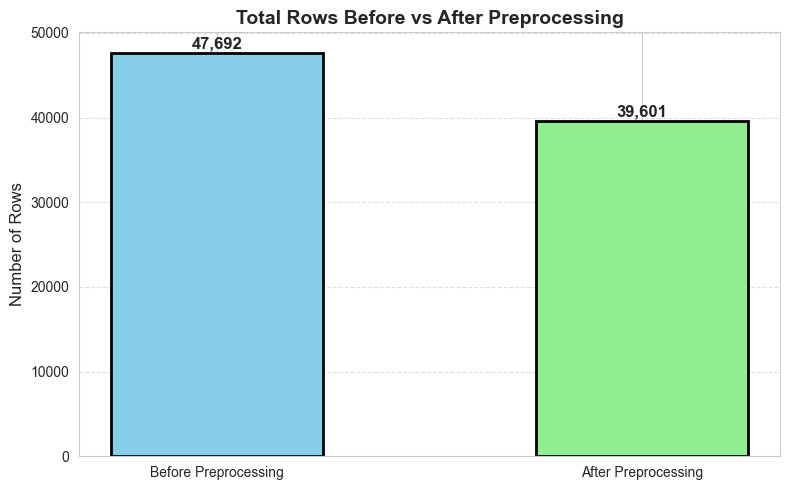

In [6]:
# Count total rows before and after
before_count = len(df)
after_count = len(preprocessed_df)

print("      Dataset Size Comparison")
print("===================================")
print(f"Before Preprocessing : {before_count:,} rows")
print(f"After Preprocessing  : {after_count:,} rows")
print(f"Rows Removed         : {before_count - after_count:,} rows ({(before_count-after_count)/before_count*100:.1f}%)")

plt.figure(figsize=(8, 5))
plt.bar(['Before Preprocessing', 'After Preprocessing'],
        [before_count, after_count],
        color=['skyblue', 'lightgreen'],
        width=0.5,
        edgecolor='black',
        linewidth=2)

# Add value labels
for i, v in enumerate([before_count, after_count]):
    plt.text(i, v + 500, f"{v:,}", ha='center', fontweight='bold', fontsize=12)

plt.title("Total Rows Before vs After Preprocessing", fontweight='bold', fontsize=14)
plt.ylabel("Number of Rows", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Word Clouds - Cleaned Data

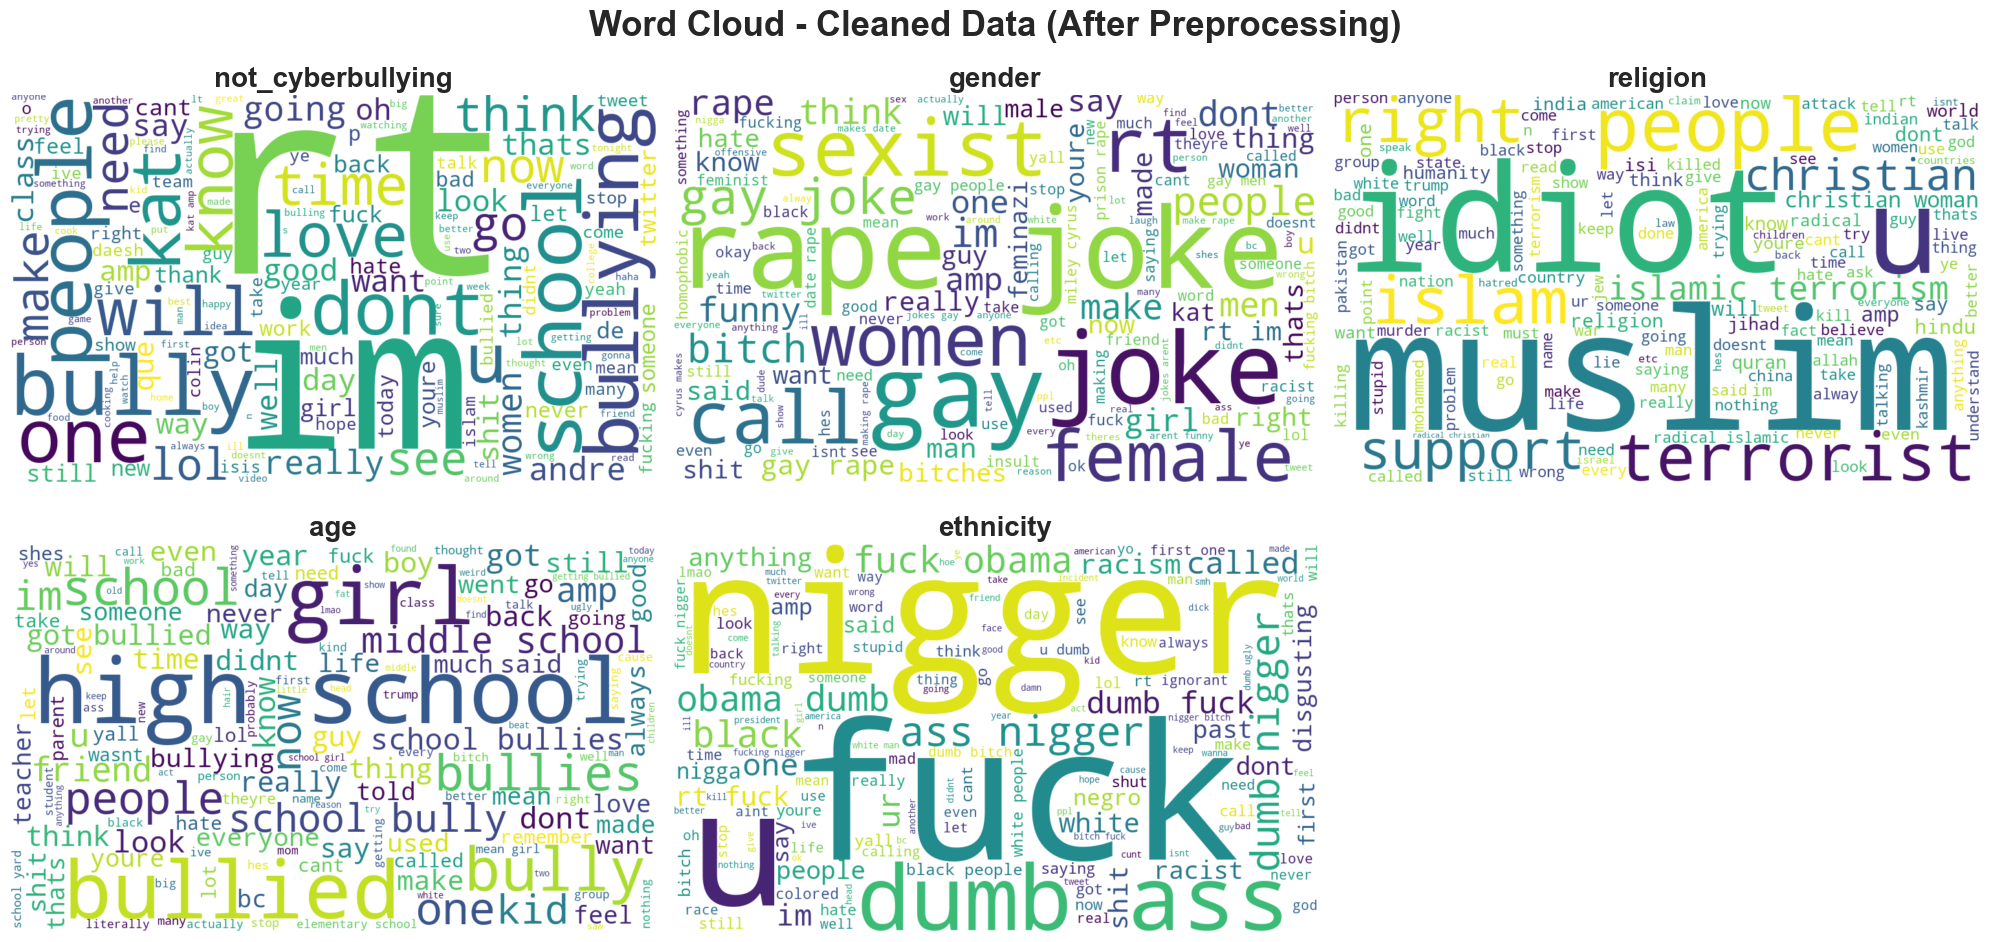

In [7]:
unique_labels = preprocessed_df['cyberbullying_type'].unique()
plt.figure(figsize=(20, 10))

for i, label in enumerate(unique_labels, 1):
    # Combine all cleaned tweets of this class
    text = " ".join(preprocessed_df[preprocessed_df['cyberbullying_type'] == label]['cleaned_text'].astype(str))
    
    # Generate word cloud
    wc = WordCloud(
        width=1000, height=600,
        background_color='white',
        colormap='viridis',
        max_words=150,
        contour_color='black',
        contour_width=2
    ).generate(text)
    
    # Plot
    plt.subplot(2, (len(unique_labels)+1)//2, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"{label}", fontsize=20, fontweight='bold')
    
plt.suptitle("Word Cloud - Cleaned Data (After Preprocessing)", fontsize=25, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## TF-IDF Feature Extraction

In [8]:
print("TF-IDF Vectorizer Configuration:")
print("=" * 50)
print("Parameters:")
print("  - ngram_range: (1, 2)      # Unigrams and bigrams")
print("  - max_features: 5000       # Top 5000 features")
print("  - stop_words: 'english'    # Remove common words")
print("\nFitting vectorizer on training data...")

# Create vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    stop_words='english'
)

# Fit on cleaned text
X_tfidf = vectorizer.fit_transform(preprocessed_df['cleaned_text'])
y = preprocessed_df['cyberbullying_type']

print(f"\n Vectorization Complete!")
print(f"Feature Matrix Shape: {X_tfidf.shape}")
print(f"  - Samples: {X_tfidf.shape[0]}")
print(f"  - Features: {X_tfidf.shape[1]}")
print(f"  - Sparse Matrix Type: {type(X_tfidf)}")
print(f"  - Density: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100:.2f}%")

TF-IDF Vectorizer Configuration:
Parameters:
  - ngram_range: (1, 2)      # Unigrams and bigrams
  - max_features: 5000       # Top 5000 features
  - stop_words: 'english'    # Remove common words

Fitting vectorizer on training data...

 Vectorization Complete!
Feature Matrix Shape: (39601, 5000)
  - Samples: 39601
  - Features: 5000
  - Sparse Matrix Type: <class 'scipy.sparse._csr.csr_matrix'>
  - Density: 0.23%


## Feature Analysis

In [9]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()
print(f"Total Features Extracted: {len(feature_names)}")
print(f"\nSample Features (First 50):")
print(feature_names[:50])

Total Features Extracted: 5000

Sample Features (First 50):
['ab' 'ability' 'able' 'abortion' 'abortions' 'absolute' 'absolutely'
 'abt' 'abuse' 'abused' 'abusing' 'abusive' 'acc' 'accept' 'acceptable'
 'accepted' 'accepting' 'access' 'accidentally' 'according' 'account'
 'accountable' 'accounts' 'accused' 'acknowledge' 'act' 'act like' 'acted'
 'acting' 'acting like' 'action' 'actions' 'active' 'actively' 'activist'
 'activists' 'activities' 'activity' 'actor' 'actors' 'acts' 'acts like'
 'actual' 'actually' 'ad' 'adam' 'add' 'added' 'address' 'administration']



Top 20 Most Important Features (by TF-IDF Score):
          feature  tfidf_score
3884       school     0.027417
1603         fuck     0.023584
1246         dumb     0.022228
3043       nigger     0.019030
3786           rt     0.018496
1956         high     0.018233
2565         like     0.018180
1958  high school     0.017113
509       bullied     0.016175
3579         rape     0.015286
2110           im     0.015208
546         bully     0.015108
2359         just     0.015104
3254       people     0.014889
1683          gay     0.014511
1176         dont     0.014456
2322        jokes     0.013767
202           ass     0.012672
1758        girls     0.012191
1739         girl     0.010790


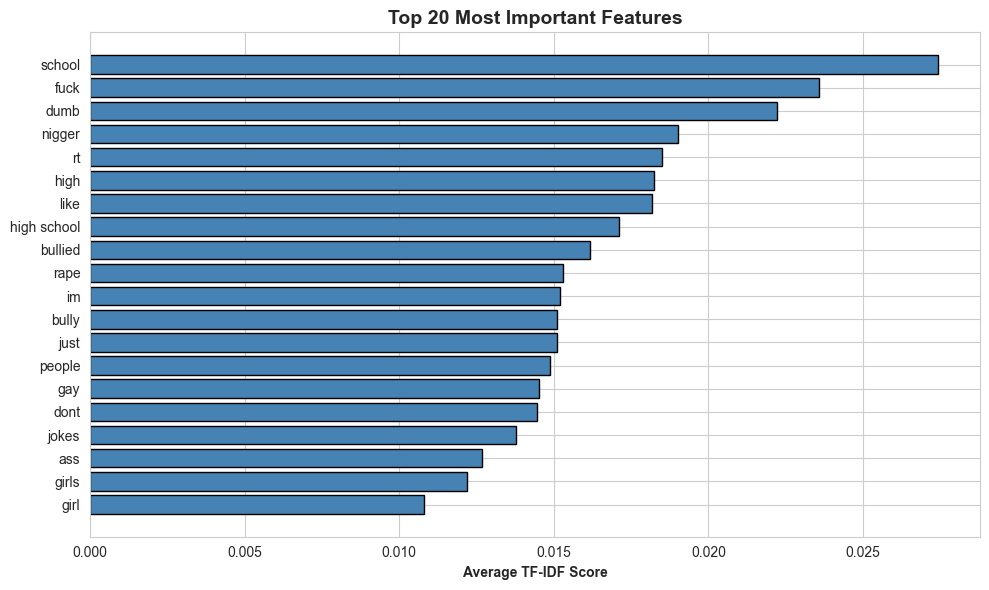

In [10]:
# Analyze feature importance (TF-IDF scores)
# Get the mean TF-IDF score for each feature
feature_importance = np.asarray(X_tfidf.mean(axis=0)).flatten()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'tfidf_score': feature_importance
}).sort_values('tfidf_score', ascending=False)

print("\nTop 20 Most Important Features (by TF-IDF Score):")
print(feature_importance_df.head(20))

# Visualize top features
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(20)
plt.barh(range(len(top_features)), top_features['tfidf_score'].values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Average TF-IDF Score', fontweight='bold')
plt.title('Top 20 Most Important Features', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Key Features by Cyberbullying Type

In [11]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# For each class, find top features
class_names = le.classes_
print("Top 10 Features for Each Cyberbullying Type:\n")
print("=" * 60)

for i, class_name in enumerate(class_names):
    class_indices = np.where(y_encoded == i)[0]
    class_tfidf = X_tfidf[class_indices].mean(axis=0)
    class_tfidf_array = np.asarray(class_tfidf).flatten()
    
    top_indices = np.argsort(class_tfidf_array)[-10:][::-1]
    top_features = feature_names[top_indices]
    top_scores = class_tfidf_array[top_indices]
    
    print(f"\n{class_name.upper()}:")
    print("-" * 60)
    for feature, score in zip(top_features, top_scores):
        print(f"  • {feature:<30} (score: {score:.4f})")

Top 10 Features for Each Cyberbullying Type:


AGE:
------------------------------------------------------------
  • school                         (score: 0.1244)
  • high                           (score: 0.0875)
  • high school                    (score: 0.0835)
  • bullied                        (score: 0.0773)
  • bully                          (score: 0.0586)
  • girls                          (score: 0.0489)
  • girl                           (score: 0.0455)
  • bullies                        (score: 0.0417)
  • bullied high                   (score: 0.0393)
  • like                           (score: 0.0295)

ETHNICITY:
------------------------------------------------------------
  • dumb                           (score: 0.1081)
  • fuck                           (score: 0.1064)
  • nigger                         (score: 0.0948)
  • ass                            (score: 0.0547)
  • dumb ass                       (score: 0.0443)
  • black                          (score: 0.0390

## Summary & Conclusions

 **Text Cleaning**: Successfully removed URLs, mentions, hashtags, punctuation  
 **Data Quality**: Removed 5,598 rows (~12%) through cleaning pipeline  
 **Feature Extraction**: TF-IDF with 5,000 features captures unigrams and bigrams  
 **Sparse Representation**: Efficient sparse matrix format for ML models  
 **Discriminative Features**: Each cyberbullying type has distinct vocabulary patterns  
 **Ready for Modeling**: Features extracted and prepared for classification

## Summary & Conclusions

**Text Cleaning**: Successfully removed URLs, mentions, hashtags, punctuation  
**Data Quality**: Removed 5,598 rows (~12%) through cleaning pipeline  
**Feature Extraction**: TF-IDF with 5,000 features captures unigrams and bigrams  
**Sparse Representation**: Efficient sparse matrix format for ML models  
**Discriminative Features**: Each cyberbullying type has distinct vocabulary patterns  
**Ready for Modeling**: Features extracted and prepared for classification

In [12]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# For each class, find top features
class_names = le.classes_
print("Top 10 Features for Each Cyberbullying Type:\n")
print("=" * 60)

for i, class_name in enumerate(class_names):
    class_indices = np.where(y_encoded == i)[0]
    class_tfidf = X_tfidf[class_indices].mean(axis=0)
    class_tfidf_array = np.asarray(class_tfidf).flatten()
    
    top_indices = np.argsort(class_tfidf_array)[-10:][::-1]
    top_features = feature_names[top_indices]
    top_scores = class_tfidf_array[top_indices]
    
    print(f"\n{class_name.upper()}:")
    print("-" * 60)
    for feature, score in zip(top_features, top_scores):
        print(f"  • {feature:<30} (score: {score:.4f})")

Top 10 Features for Each Cyberbullying Type:


AGE:
------------------------------------------------------------
  • school                         (score: 0.1244)
  • high                           (score: 0.0875)
  • high school                    (score: 0.0835)
  • bullied                        (score: 0.0773)
  • bully                          (score: 0.0586)
  • girls                          (score: 0.0489)
  • girl                           (score: 0.0455)
  • bullies                        (score: 0.0417)
  • bullied high                   (score: 0.0393)
  • like                           (score: 0.0295)

ETHNICITY:
------------------------------------------------------------
  • dumb                           (score: 0.1081)
  • fuck                           (score: 0.1064)
  • nigger                         (score: 0.0948)
  • ass                            (score: 0.0547)
  • dumb ass                       (score: 0.0443)
  • black                          (score: 0.0390

## Key Features by Cyberbullying Type


Top 20 Most Important Features (by TF-IDF Score):
          feature  tfidf_score
3884       school     0.027417
1603         fuck     0.023584
1246         dumb     0.022228
3043       nigger     0.019030
3786           rt     0.018496
1956         high     0.018233
2565         like     0.018180
1958  high school     0.017113
509       bullied     0.016175
3579         rape     0.015286
2110           im     0.015208
546         bully     0.015108
2359         just     0.015104
3254       people     0.014889
1683          gay     0.014511
1176         dont     0.014456
2322        jokes     0.013767
202           ass     0.012672
1758        girls     0.012191
1739         girl     0.010790


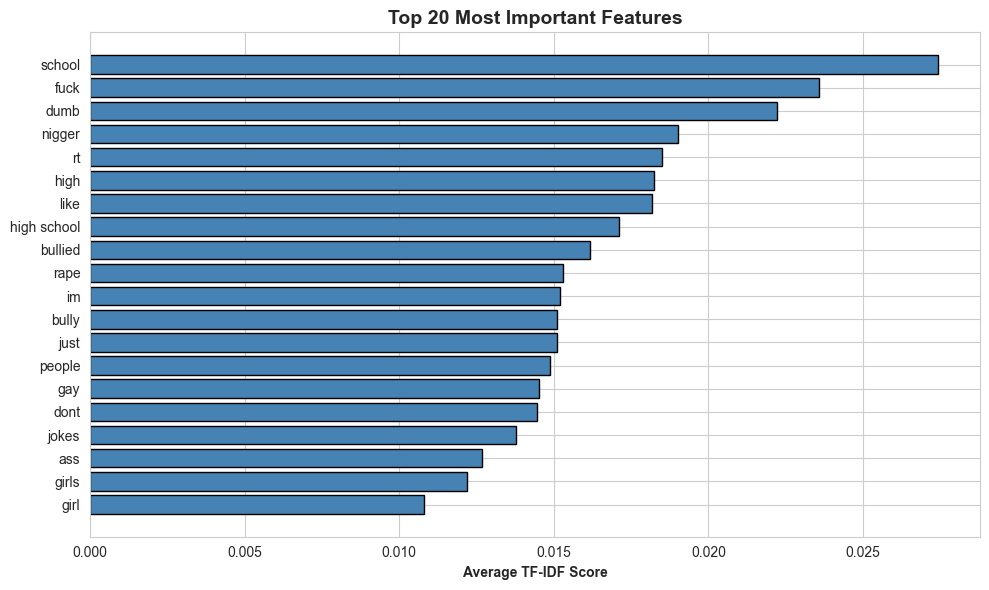

In [13]:
# Analyze feature importance (TF-IDF scores)
# Get the mean TF-IDF score for each feature
feature_importance = np.asarray(X_tfidf.mean(axis=0)).flatten()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'tfidf_score': feature_importance
}).sort_values('tfidf_score', ascending=False)

print("\nTop 20 Most Important Features (by TF-IDF Score):")
print(feature_importance_df.head(20))

# Visualize top features
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(20)
plt.barh(range(len(top_features)), top_features['tfidf_score'].values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Average TF-IDF Score', fontweight='bold')
plt.title('Top 20 Most Important Features', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()
print(f"Total Features Extracted: {len(feature_names)}")
print(f"\nSample Features (First 50):")
print(feature_names[:50])

Total Features Extracted: 5000

Sample Features (First 50):
['ab' 'ability' 'able' 'abortion' 'abortions' 'absolute' 'absolutely'
 'abt' 'abuse' 'abused' 'abusing' 'abusive' 'acc' 'accept' 'acceptable'
 'accepted' 'accepting' 'access' 'accidentally' 'according' 'account'
 'accountable' 'accounts' 'accused' 'acknowledge' 'act' 'act like' 'acted'
 'acting' 'acting like' 'action' 'actions' 'active' 'actively' 'activist'
 'activists' 'activities' 'activity' 'actor' 'actors' 'acts' 'acts like'
 'actual' 'actually' 'ad' 'adam' 'add' 'added' 'address' 'administration']


## Feature Analysis

In [15]:
print("TF-IDF Vectorizer Configuration:")
print("=" * 50)
print("Parameters:")
print("  - ngram_range: (1, 2)      # Unigrams and bigrams")
print("  - max_features: 5000       # Top 5000 features")
print("  - stop_words: 'english'    # Remove common words")
print("\nFitting vectorizer on training data...")

# Create vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    stop_words='english'
)

# Fit on cleaned text
X_tfidf = vectorizer.fit_transform(preprocessed_df['cleaned_text'])
y = preprocessed_df['cyberbullying_type']

print(f"\n Vectorization Complete!")
print(f"Feature Matrix Shape: {X_tfidf.shape}")
print(f"  - Samples: {X_tfidf.shape[0]}")
print(f"  - Features: {X_tfidf.shape[1]}")
print(f"  - Sparse Matrix Type: {type(X_tfidf)}")
print(f"  - Density: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100:.2f}%")

TF-IDF Vectorizer Configuration:
Parameters:
  - ngram_range: (1, 2)      # Unigrams and bigrams
  - max_features: 5000       # Top 5000 features
  - stop_words: 'english'    # Remove common words

Fitting vectorizer on training data...

 Vectorization Complete!
Feature Matrix Shape: (39601, 5000)
  - Samples: 39601
  - Features: 5000
  - Sparse Matrix Type: <class 'scipy.sparse._csr.csr_matrix'>
  - Density: 0.23%


## TF-IDF Feature Extraction

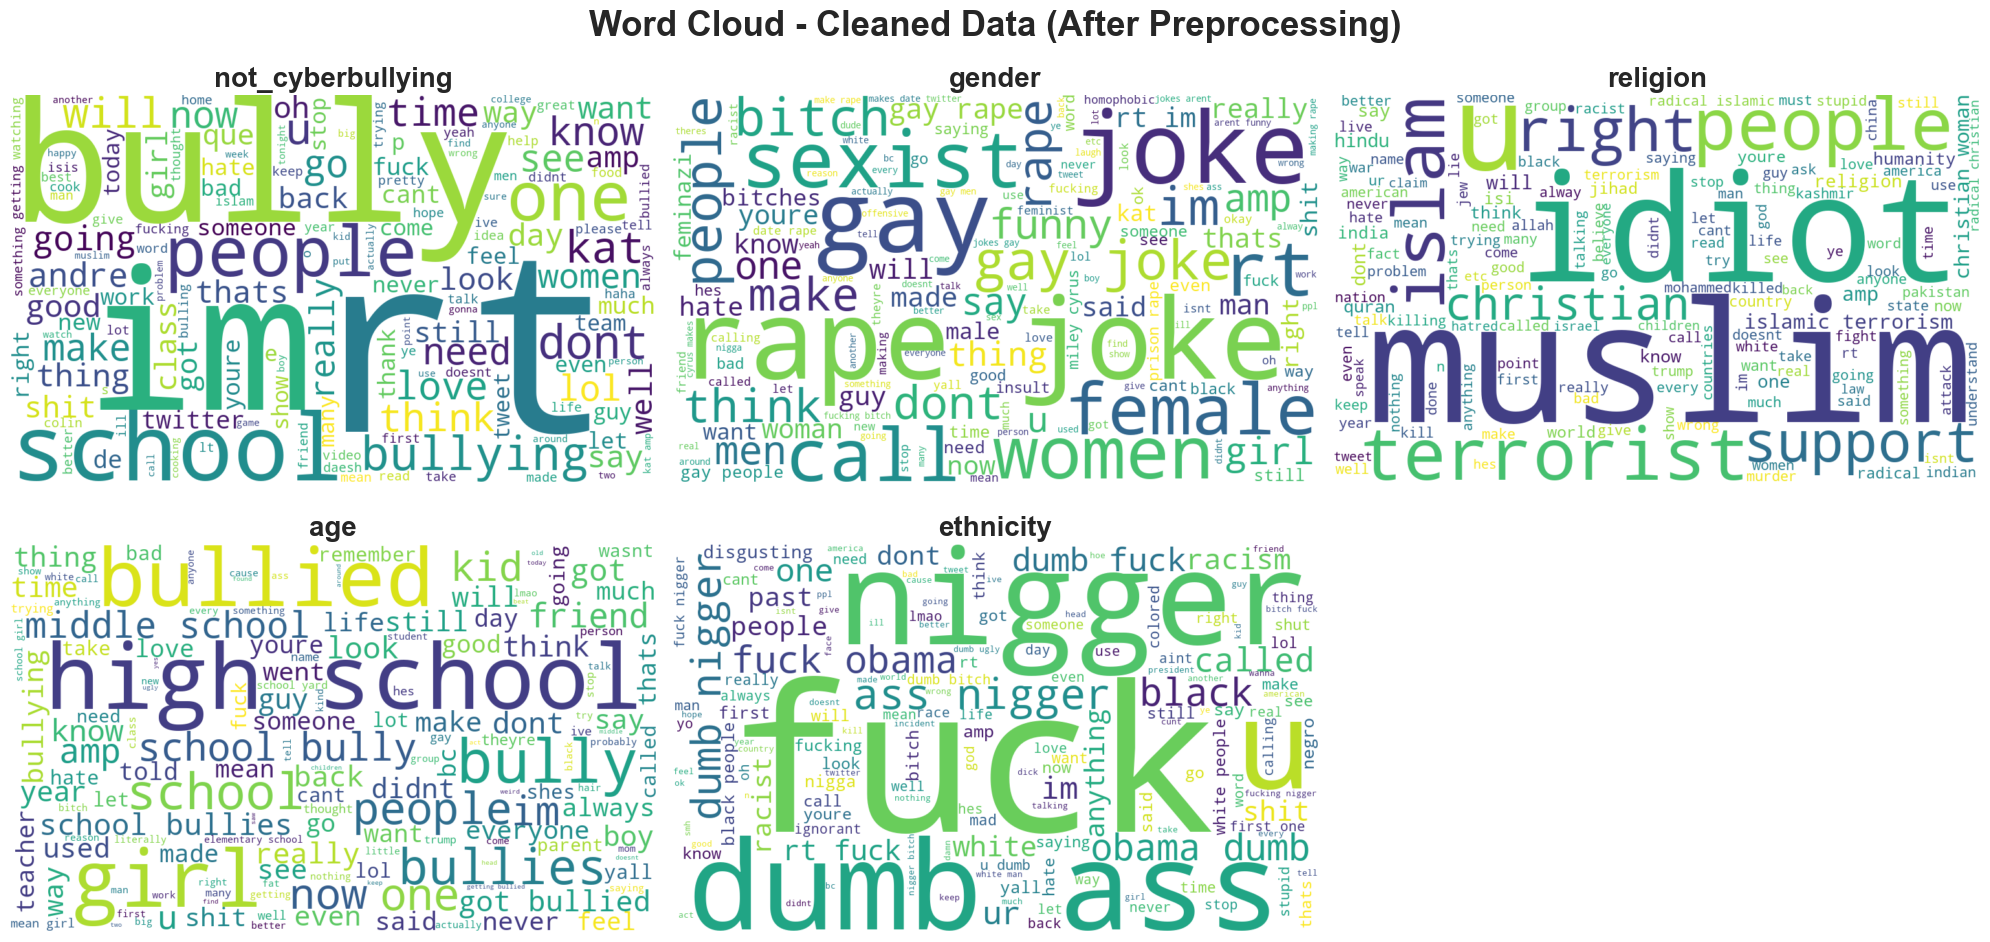

In [16]:
unique_labels = preprocessed_df['cyberbullying_type'].unique()
plt.figure(figsize=(20, 10))

for i, label in enumerate(unique_labels, 1):
    # Combine all cleaned tweets of this class
    text = " ".join(preprocessed_df[preprocessed_df['cyberbullying_type'] == label]['cleaned_text'].astype(str))
    
    # Generate word cloud
    wc = WordCloud(
        width=1000, height=600,
        background_color='white',
        colormap='viridis',
        max_words=150,
        contour_color='black',
        contour_width=2
    ).generate(text)
    
    # Plot
    plt.subplot(2, (len(unique_labels)+1)//2, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"{label}", fontsize=20, fontweight='bold')
    
plt.suptitle("Word Cloud - Cleaned Data (After Preprocessing)", fontsize=25, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Word Clouds - Cleaned Data

      Dataset Size Comparison
Before Preprocessing : 47,692 rows
After Preprocessing  : 39,601 rows
Rows Removed         : 8,091 rows (17.0%)


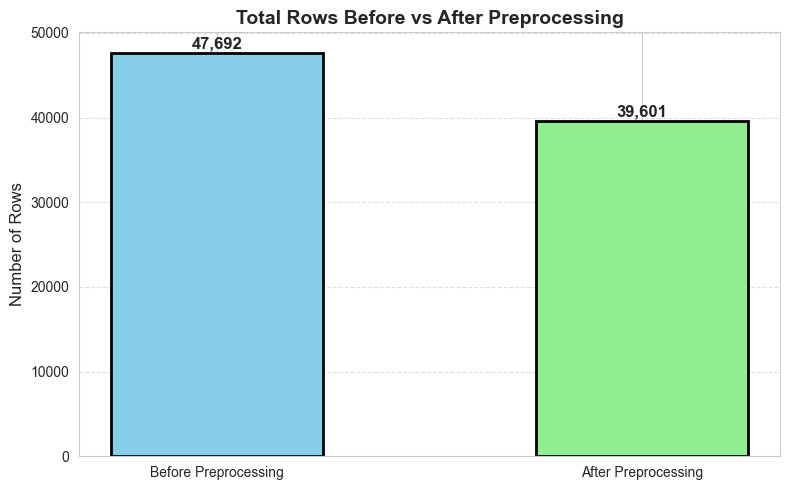

In [17]:
# Count total rows before and after
before_count = len(df)
after_count = len(preprocessed_df)

print("      Dataset Size Comparison")
print("==================================")
print(f"Before Preprocessing : {before_count:,} rows")
print(f"After Preprocessing  : {after_count:,} rows")
print(f"Rows Removed         : {before_count - after_count:,} rows ({(before_count-after_count)/before_count*100:.1f}%)")

plt.figure(figsize=(8, 5))
plt.bar(['Before Preprocessing', 'After Preprocessing'],
        [before_count, after_count],
        color=['skyblue', 'lightgreen'],
        width=0.5,
        edgecolor='black',
        linewidth=2)

# Add value labels
for i, v in enumerate([before_count, after_count]):
    plt.text(i, v + 500, f"{v:,}", ha='center', fontweight='bold', fontsize=12)

plt.title("Total Rows Before vs After Preprocessing", fontweight='bold', fontsize=14)
plt.ylabel("Number of Rows", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Data Size Comparison

In [18]:
print("\nPreview of Cleaned Data:")
print(preprocessed_df[['tweet_text', 'cyberbullying_type', 'cleaned_text']].head(10))


Preview of Cleaned Data:
                                          tweet_text cyberbullying_type  \
0  In other words #katandandre, your food was cra...  not_cyberbullying   
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying   
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying   
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying   
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying   
5  @Raja5aab @Quickieleaks Yes, the test of god i...  not_cyberbullying   
6  Itu sekolah ya bukan tempat bully! Ga jauh kay...  not_cyberbullying   
7  Karma. I hope it bites Kat on the butt. She is...  not_cyberbullying   
8       @stockputout everything but mostly my priest  not_cyberbullying   
9  Rebecca Black Drops Out of School Due to Bully...  not_cyberbullying   

                                        cleaned_text  
0          in other words your food was crapilicious  
1                                    w

In [19]:
preprocessed_df = df.copy()

# Step 1: Check and drop null values
print("Step 1: Handling Missing Values")
print(f"Missing values: {preprocessed_df.isnull().sum().sum()}")
preprocessed_df = preprocessed_df.dropna(subset=['tweet_text', 'cyberbullying_type'])
print(f"Shape after removing nulls: {preprocessed_df.shape}")

# Step 2: Remove duplicate tweets
print("\nStep 2: Removing Duplicates")
initial_size = len(preprocessed_df)
preprocessed_df = preprocessed_df.drop_duplicates(subset=['tweet_text']).reset_index(drop=True)
print(f"Duplicates removed: {initial_size - len(preprocessed_df)}")
print(f"Shape after removing duplicates: {preprocessed_df.shape}")

# Step 3: Remove unwanted class
print("\nStep 3: Removing 'other_cyberbullying' class")
initial_size = len(preprocessed_df)
preprocessed_df = preprocessed_df[preprocessed_df['cyberbullying_type'] != 'other_cyberbullying'].reset_index(drop=True)
print(f"Samples removed: {initial_size - len(preprocessed_df)}")
print(f"Shape after removing class: {preprocessed_df.shape}")

# Step 4: Remove empty tweets
print("\nStep 4: Removing empty tweets")
initial_size = len(preprocessed_df)
preprocessed_df = preprocessed_df[preprocessed_df['tweet_text'].astype(str).str.strip() != ""]
preprocessed_df.reset_index(drop=True, inplace=True)
print(f"Empty tweets removed: {initial_size - len(preprocessed_df)}")

# Step 5: Apply text cleaning
print("\nStep 5: Applying text cleaning function")
preprocessed_df['cleaned_text'] = preprocessed_df['tweet_text'].apply(clean_text)

# Step 6: Remove empty after cleaning
initial_size = len(preprocessed_df)
preprocessed_df = preprocessed_df[preprocessed_df['cleaned_text'].astype(str).str.strip() != ""].reset_index(drop=True)
preprocessed_df = preprocessed_df[preprocessed_df['cleaned_text'].str.len()>0]
print(f"Empty after cleaning: {initial_size - len(preprocessed_df)}")
print(f"Final shape after preprocessing: {preprocessed_df.shape}")

print("\n Text cleaning process complete")

Step 1: Handling Missing Values
Missing values: 0
Shape after removing nulls: (47692, 2)

Step 2: Removing Duplicates
Duplicates removed: 1675
Shape after removing duplicates: (46017, 2)

Step 3: Removing 'other_cyberbullying' class
Samples removed: 6243
Shape after removing class: (39774, 2)

Step 4: Removing empty tweets
Empty tweets removed: 0

Step 5: Applying text cleaning function
Empty after cleaning: 173
Final shape after preprocessing: (39601, 3)

 Text cleaning process complete


## Preprocessing Pipeline

In [20]:
def clean_text(text):
    """
    Clean and preprocess text data.
    - Convert to lowercase
    - Remove URLs
    - Remove @mentions
    - Remove #hashtags
    - Remove punctuation and numbers
    - Remove extra whitespace
    """
    text = text.lower()                         # lowercase
    text = re.sub(r"http\S+", "", text)         # remove URLs
    text = re.sub(r"@\w+", "", text)            # remove mentions
    text = re.sub(r"#\w+", "", text)            # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)        # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

# Test the cleaning function
sample_text = df['tweet_text'].iloc[0]
print("Original Text:")
print(repr(sample_text[:100]))
print("\nCleaned Text:")
print(repr(clean_text(sample_text)[:100]))

Original Text:
'In other words #katandandre, your food was crapilicious! #mkr'

Cleaned Text:
'in other words your food was crapilicious'
